In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
 
# =============================================================
# PROJECT 2 — SMS Spam Detection
# Model: Logistic Regression + Bag of Words (CountVectorizer)
# Dataset: SMS Spam Collection (5,574 real SMS messages)
# Task: Binary Classification → ham (0) or spam (1)
# =============================================================
 
# ─────────────────────────────────────────────
# STEP 1: Load and Explore the Data
# The dataset contains real SMS messages labeled as:
#   - "ham"  → legitimate message
#   - "spam" → unwanted/promotional message
# ─────────────────────────────────────────────
 
print("=" * 60)
print("STEP 1 — Load and Explore the Data")
print("=" * 60)
 
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
 
print(df.head(10))
print(f"\nTotal messages   : {len(df):,}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
print(f"\nSpam percentage  : {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")
print(f"Ham  percentage  : {df['label'].value_counts(normalize=True)['ham']*100:.1f}%")
print("\nNote: The dataset is imbalanced — most messages are ham.")
print("This is realistic; in real life, spam is the minority class.")

STEP 1 — Load and Explore the Data
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
5  spam  FreeMsg Hey there darling it's been 3 week's n...
6   ham  Even my brother is not like to speak with me. ...
7   ham  As per your request 'Melle Melle (Oru Minnamin...
8  spam  WINNER!! As a valued network customer you have...
9  spam  Had your mobile 11 months or more? U R entitle...

Total messages   : 5,572

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage  : 13.4%
Ham  percentage  : 86.6%

Note: The dataset is imbalanced — most messages are ham.
This is realistic; in real life, spam is the minority class.


In [2]:
# ─────────────────────────────────────────────
# STEP 2: Add a New Column — Message Length
# Why: Spam messages tend to be longer (lots of promotional text).
# This is a quick EDA (Exploratory Data Analysis) insight.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 60)
print("STEP 2 — EDA: Message Length Analysis")
print("=" * 60)
 
df['msg_length'] = df['message'].apply(len)
 
ham_avg  = df[df['label'] == 'ham']['msg_length'].mean()
spam_avg = df[df['label'] == 'spam']['msg_length'].mean()
 
print(f"Average ham  message length : {ham_avg:.1f} characters")
print(f"Average spam message length : {spam_avg:.1f} characters")
print("→ Spam messages are noticeably longer on average.")


STEP 2 — EDA: Message Length Analysis
Average ham  message length : 71.5 characters
Average spam message length : 138.7 characters
→ Spam messages are noticeably longer on average.


In [ ]:
# ─────────────────────────────────────────────
# STEP 3: Encode the Target Label
# Machine learning models require numeric inputs.
# We map: spam → 1, ham → 0
# ─────────────────────────────────────────────
 
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

 

In [4]:
# ─────────────────────────────────────────────
# STEP 4: Text Vectorization — Bag of Words
# CountVectorizer converts each message into a numeric vector.
# Each element counts how many times a word appears in that message.
# Parameters used:
#   - stop_words='english' → ignores common words (the, is, a...)
#   - max_features=500     → keeps only the 500 most frequent words
# ─────────────────────────────────────────────
 
print("\n" + "=" * 60)
print("STEP 4 — Text Vectorization (Bag of Words)")
print("=" * 60)
 
vectorizer = CountVectorizer(stop_words='english', max_features=500)
X = vectorizer.fit_transform(df['message'])
y = df['label_num']
 
print(f"Matrix shape     : {X.shape}  → (messages × features)")
print(f"Each row         : one SMS message")
print(f"Each column      : word count for one of the 500 top words")
print(f"\nSample features  : {list(vectorizer.get_feature_names_out()[:15])}")
print("\nExample: the word 'free' appearing many times → likely spam.")


STEP 4 — Text Vectorization (Bag of Words)
Matrix shape     : (5572, 500)  → (messages × features)
Each row         : one SMS message
Each column      : word count for one of the 500 top words

Sample features  : ['000', '10', '100', '1000', '10p', '11', '12hrs', '150', '150p', '150ppm', '16', '18', '1st', '2000', '250']

Example: the word 'free' appearing many times → likely spam.


In [5]:
# ─────────────────────────────────────────────
# STEP 5: Train / Test Split
# 80% of data for training, 20% for testing.
# Stratify ensures both splits have the same spam/ham ratio.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 60)
print("STEP 5 — Train / Test Split")
print("=" * 60)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print(f"Training set : {X_train.shape[0]:,} messages")
print(f"Test set     : {X_test.shape[0]:,} messages")
print("Note: stratify=y ensures class balance is preserved in both sets.")
 


STEP 5 — Train / Test Split
Training set : 4,457 messages
Test set     : 1,115 messages
Note: stratify=y ensures class balance is preserved in both sets.


In [6]:
# ─────────────────────────────────────────────
# STEP 6: Train the Model — Logistic Regression
# Why Logistic Regression for classification?
#   - Outputs a probability between 0 and 1
#   - Uses a threshold (default 0.5) to decide: spam or ham
#   - Fast, interpretable, and works well with text
# ─────────────────────────────────────────────
 
print("\n" + "=" * 60)
print("STEP 6 — Model Training (Logistic Regression)")
print("=" * 60)
 
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model training complete.")
print("The model learned which words are most associated with spam vs ham.")


STEP 6 — Model Training (Logistic Regression)
Model training complete.
The model learned which words are most associated with spam vs ham.


In [7]:
# ─────────────────────────────────────────────
# STEP 7: Top Spam and Ham Words
# Words with the highest positive coefficients → most spammy
# Words with the highest negative coefficients → most ham-like
# ─────────────────────────────────────────────
 
print("\n" + "=" * 60)
print("STEP 7 — Most Influential Words")
print("=" * 60)
 
feature_names = vectorizer.get_feature_names_out()
coefs         = model.coef_[0]
 
top_spam_idx = np.argsort(coefs)[-10:][::-1]
top_ham_idx  = np.argsort(coefs)[:10]
 
print("Top 10 words that indicate SPAM:")
for i in top_spam_idx:
    print(f"  {feature_names[i]:15s}  coef = {coefs[i]:+.3f}")
 
print("\nTop 10 words that indicate HAM:")
for i in top_ham_idx:
    print(f"  {feature_names[i]:15s}  coef = {coefs[i]:+.3f}")
 


STEP 7 — Most Influential Words
Top 10 words that indicate SPAM:
  uk               coef = +3.039
  service          coef = +2.826
  150p             coef = +2.263
  min              coef = +2.258
  txt              coef = +2.238
  50               coef = +2.040
  claim            coef = +1.973
  mobile           coef = +1.933
  order            coef = +1.896
  urgent           coef = +1.811

Top 10 words that indicate HAM:
  gt               coef = -1.789
  lt               coef = -1.778
  people           coef = -1.364
  ll               coef = -1.053
  later            coef = -1.013
  sorry            coef = -0.988
  ok               coef = -0.966
  da               coef = -0.878
  mail             coef = -0.871
  happy            coef = -0.869


In [8]:
# ─────────────────────────────────────────────
# STEP 8: Model Evaluation
# Accuracy alone is misleading for imbalanced datasets.
# We use a full classification report:
#   - Precision : of all predicted spam, how many were actually spam?
#   - Recall    : of all actual spam, how many did we catch?
#   - F1-Score  : harmonic mean of precision and recall
# ─────────────────────────────────────────────
 
print("\n" + "=" * 60)
print("STEP 8 — Model Evaluation")
print("=" * 60)
 
y_pred   = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
 
print(f"Accuracy : {accuracy:.4f}  → {accuracy*100:.1f}% of messages correctly classified")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['ham (0)', 'spam (1)']))
 


STEP 8 — Model Evaluation
Accuracy : 0.9767  → 97.7% of messages correctly classified

Detailed Classification Report:
              precision    recall  f1-score   support

     ham (0)       0.98      1.00      0.99       966
    spam (1)       0.98      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115




STEP 9 — Confusion Matrix
  TN (ham  → ham,  correct) :  964  ✅
  TP (spam → spam, correct) :  125  ✅
  FP (ham  → spam, wrong)   :    2  ❌ ham blocked (false alarm)
  FN (spam → ham,  wrong)   :   24  ❌ spam slipped through (missed)


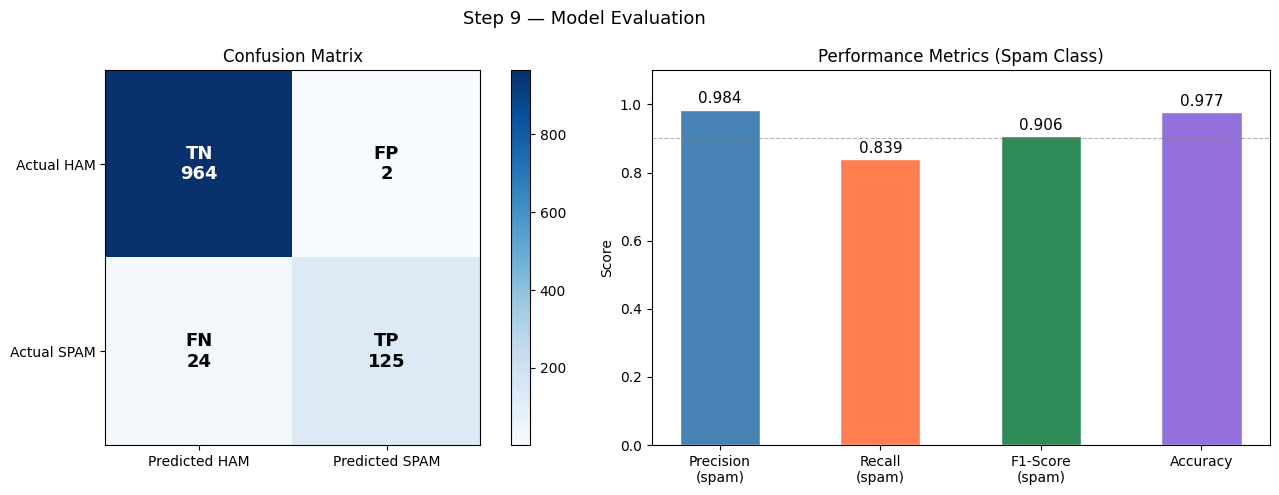

In [9]:
# ─────────────────────────────────────────────
# STEP 9: Confusion Matrix — Understanding Errors
#
#   Confusion Matrix Layout:
#
#                  Predicted HAM    Predicted SPAM
#   Actual HAM  |      TN         |      FP        |
#   Actual SPAM |      FN         |      TP        |
#
#   TN (True Negative)  = ham correctly classified as ham   ✅
#   TP (True Positive)  = spam correctly classified as spam ✅
#   FP (False Positive) = ham wrongly classified as spam    ❌ (annoying)
#   FN (False Negative) = spam missed, classified as ham    ❌ (dangerous)
#
# In spam detection, FN (missed spam) is worse than FP (blocked ham).
# ─────────────────────────────────────────────
 
print("\n" + "=" * 60)
print("STEP 9 — Confusion Matrix")
print("=" * 60)
 
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
 
print(f"  TN (ham  → ham,  correct) : {TN:4d}  ✅")
print(f"  TP (spam → spam, correct) : {TP:4d}  ✅")
print(f"  FP (ham  → spam, wrong)   : {FP:4d}  ❌ ham blocked (false alarm)")
print(f"  FN (spam → ham,  wrong)   : {FN:4d}  ❌ spam slipped through (missed)")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 9 — Model Evaluation", fontsize=13)
 
# ── Left: Confusion Matrix ─────────────────
ax = axes[0]
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted HAM', 'Predicted SPAM'], fontsize=10)
ax.set_yticklabels(['Actual HAM', 'Actual SPAM'], fontsize=10)
ax.set_title("Confusion Matrix")
 
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]}",
                ha='center', va='center', color=color, fontsize=13, fontweight='bold')
 
plt.colorbar(im, ax=ax)
 
# ── Right: Precision / Recall / F1 Bar Chart ─
ax2 = axes[1]
from sklearn.metrics import precision_score, recall_score, f1_score
 
metrics = {
    'Precision\n(spam)': precision_score(y_test, y_pred),
    'Recall\n(spam)':    recall_score(y_test, y_pred),
    'F1-Score\n(spam)':  f1_score(y_test, y_pred),
    'Accuracy':          accuracy,
}
 
bars = ax2.bar(metrics.keys(), metrics.values(),
               color=['steelblue', 'coral', 'seagreen', 'mediumpurple'],
               edgecolor='white', width=0.5)
 
for bar, val in zip(bars, metrics.values()):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', va='bottom', fontsize=11)
 
ax2.set_ylim(0, 1.1)
ax2.set_title("Performance Metrics (Spam Class)")
ax2.set_ylabel("Score")
ax2.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
 
plt.tight_layout()
plt.savefig("spam_evaluation.png", dpi=150)
plt.show()

In [10]:
# ─────────────────────────────────────────────
# STEP 10: Test on Custom Messages
# The predict_spam function lets you test any text in real-time.
# It returns the label AND the model's confidence percentage.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 60)
print("STEP 10 — Testing on Custom Messages")
print("=" * 60)
 
def predict_spam(message):
    """
    Classifies a single SMS message as SPAM or HAM.
    Uses the trained Logistic Regression + CountVectorizer pipeline.
 
    Args:
        message (str): The SMS text to classify.
 
    Returns:
        None — prints the label and confidence score.
    """
    vec   = vectorizer.transform([message])
    pred  = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
 
    label      = "SPAM 🚨" if pred == 1 else "HAM  ✅"
    confidence = proba[pred] * 100
 
    print(f"  Message    : {message[:70]}{'...' if len(message)>70 else ''}")
    print(f"  Prediction : {label}   (confidence: {confidence:.1f}%)")
    print()
 
# Test messages — covering clear spam, clear ham, and edge cases
test_messages = [
    ("Congratulations! You won a FREE iPhone. Click now to claim your prize!",  "→ obvious spam"),
    ("Hey, are we still meeting tomorrow for lunch?",                            "→ obvious ham"),
    ("URGENT: Your account has been compromised. Call us immediately!",          "→ obvious spam"),
    ("أهلاً، كيف حالك؟ هل أنت بخير؟",                                           "→ Arabic ham (non-English)"),
    ("Hi, I have a question about our project. Can we talk later?",             "→ ham"),
    ("Win cash prizes every week! Text WIN to 87121 now. Free entry!",          "→ spam"),
    ("Don't forget to bring the documents for tomorrow's meeting.",             "→ ham"),
    ("You have been selected for a $1000 Walmart gift card. Claim now!",        "→ spam"),
]
 
for msg, note in test_messages:
    print(f"  [{note}]")
    predict_spam(msg)
 
print("=" * 60)
print("✅ All steps complete. Plot saved as 'spam_evaluation.png'")
print("=" * 60)


STEP 10 — Testing on Custom Messages
  [→ obvious spam]
  Message    : Congratulations! You won a FREE iPhone. Click now to claim your prize!
  Prediction : SPAM 🚨   (confidence: 91.8%)

  [→ obvious ham]
  Message    : Hey, are we still meeting tomorrow for lunch?
  Prediction : HAM  ✅   (confidence: 99.5%)

  [→ obvious spam]
  Message    : URGENT: Your account has been compromised. Call us immediately!
  Prediction : HAM  ✅   (confidence: 72.0%)

  [→ Arabic ham (non-English)]
  Message    : أهلاً، كيف حالك؟ هل أنت بخير؟
  Prediction : HAM  ✅   (confidence: 97.7%)

  [→ ham]
  Message    : Hi, I have a question about our project. Can we talk later?
  Prediction : HAM  ✅   (confidence: 99.1%)

  [→ spam]
  Message    : Win cash prizes every week! Text WIN to 87121 now. Free entry!
  Prediction : SPAM 🚨   (confidence: 97.3%)

  [→ ham]
  Message    : Don't forget to bring the documents for tomorrow's meeting.
  Prediction : HAM  ✅   (confidence: 99.2%)

  [→ spam]
  Message    : You 